# 05 · 注意力分块计算与反向传播实验报告

本报告汇总 01–04 的实验结果。主要内容包括：推导并实现分块注意力计算，在反向传播时重新计算所需权重，以及检查输出、梯度和显存占用。完整推导和代码见 02、03，这里整理主要思路和实验结果。04 补充 INT8 量化实验，PyTorch 内置注意力的测速结果作为对照。

项目使用 Python 和 PyTorch 实现，GPU 运算由 PyTorch 完成。本 notebook 读取已有结果并生成图表，不重新进行注意力测速。02 已完成五轮复测，其他性能数据沿用原运行；实验设置和测量方法随结果文件保存。

**目录**

1. [实验目标与主要结果](#1-实验目标与主要结果)
2. [实验设置与测量方法](#2-实验设置与测量方法)
3. [分块计算与反向传播检查](#3-分块计算与反向传播检查)
4. [显存与保存数据的分析](#4-显存与保存数据的分析)
5. [PyTorch 内置注意力的测速对照](#5-pytorch-内置注意力的测速对照)
6. [扩展实验：INT8 量化](#6-扩展实验int8-量化)
7. [实验不足与后续计划](#7-实验不足与后续计划)
8. [参考资料与结果文件](#8-参考资料与结果文件)


## 1 实验目标与主要结果

| 实验目标 | 完成的工作 | 主要结果 |
| --- | --- | --- |
| 把注意力分块计算，同时保证输出结果一致 | 推导每行最大值、指数和与输出的更新公式，编写分块前向计算 | 02 的 10 项前向检查和 5 项精度检查通过，前向检查最大绝对误差约 **6.26e-07**；见第 3 节 |
| 不保存完整权重，在反向传播时重新计算梯度 | 根据前向输出和每行统计量重新计算权重，再按块累加 $dQ,dK,dV$ | 03 普通与因果模式的梯度检查通过，与自动求导结果的最大绝对误差约 **1.13e-06**；见第 3 节 |
| 观察分块后显存占用和保存数据量的变化 | 测量前向新增显存峰值，按公式估算反向需要保留的数据 | 02 / 03 所列配置的前向峰值分别约为 math 的 **1/8.70、1/8.47**；反向数据量的估算见第 4 节 |
| 了解 INT8 量化对误差、存储和速度的影响 | 编写量化模拟，测试 CPU 动态 INT8，完成小型量化训练示例 | 四个投影层的权重数据约 **4.00× 压缩**；完整 MHA 的速度随序列长度变化，见第 6 节 |

本实验参考已有方法完成推导和代码实现，重点检查输出、梯度及存储变化。量化实验作为补充，内置注意力测速作为对照；Python 实现的运行速度和测量波动放在第 7 节说明。


## 2 实验设置与测量方法

| Notebook | 主要内容 | 性能实验设置 | 比较内容 |
| --- | --- | --- | --- |
| [01 标准注意力](01_standard_attention.ipynb) | 编写注意力、因果掩码与 MHA，检查输出 | GPU 前向；FP32，$B=1,h=1,d_k=64$ | 完整注意力矩阵的显存占用 |
| [02 Online Softmax](02_online_softmax.ipynb) | 推导逐块更新方法，实现分块前向 | GPU 前向；FP16，$B=1,h=4,d_k=64$ | 分块实现与 math 的显存差别，补充五轮测速 |
| [03 FlashAttention](03_flash_attention.ipynb) | 实现 v1 / v2 风格前向，推导并检查重计算反向 | GPU 前向；FP16，$B=1,h=8,d_k=64$ | 前向显存、反向保存数据量，以及内置实现的速度 |
| [04 INT8 量化](04_int8_quantization.ipynb) | 量化模拟、CPU 动态 INT8、梯度近似与小型 QAT | GPU：FP32，$h=2,d_k=32$；CPU：FP32 输入，$h=4,d_k=32$；均 $B=1$ | 输出误差、存储大小和运行时间 |

上表是测速时的设置，输出和梯度检查使用的输入见第 3 节。$N,B,h,d_k$ 分别表示序列长度、批次大小、注意力头数和每个头的维度。MHA 表示多头注意力，SDPA 是 PyTorch 的缩放点积注意力接口。

各组实验的头数和精度不同，因此分别画图，只比较同一实验中设置一致的方法。测速均使用普通注意力，关闭梯度，不使用 dropout。因果模式表示每个位置只能关注当前位置和之前的位置，在正确性检查中另外测试。

02 的结果保存了输入形状、头数和 PyTorch 版本。较早结果中缺少的部分设置，按照对应 notebook 的代码补充并标明来源。汇总表保留成功、跳过和不可用的记录，图表只使用成功的测速结果。


In [1]:
import platform
import sys
from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
print(f"运行系统: {platform.system()} {platform.release()}")
print(f"Python: {sys.version.split()[0]}")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

matplotlib.rcParams["font.family"] = ["DejaVu Sans", "sans-serif"]
pd.set_option("display.max_columns", 16)

# 支持从项目根目录或 notebooks/ 运行。
project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "notebooks" / "01_standard_attention.ipynb").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("请从项目根目录或 notebooks/ 运行这个 Notebook")
results_dir = project_root / "results"

def read_result(name):
    path = results_dir / name
    if not path.is_file():
        raise FileNotFoundError(f"缺少 {path.name}，请先运行生成它的 Notebook")
    raw = path.read_bytes()
    return json.loads(raw.decode("utf-8"))

def save_figure(fig, name):
    fig.tight_layout()
    fig.savefig(results_dir / name, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"读取目录：{results_dir}")
print(f"分析依赖：pandas {pd.__version__}，NumPy {np.__version__}")
print("本节无需 CUDA；原实验的设备信息从结果文件读取。")

运行系统: Linux 6.6.87.2-microsoft-standard-WSL2
Python: 3.10.12


读取目录：/mnt/e/Programming/efficient-attention-lab-rerun02-20261004-155032/project/results
分析依赖：pandas 2.3.3，NumPy 2.2.6
本节无需 CUDA；原实验的设备信息从结果文件读取。


In [2]:
benchmark_files = {
    "01": "01_benchmark_standard_attention.json",
    "02": "02_benchmark_online_softmax.json",
    "03": "03_benchmark_flash_attention.json",
    "04": "04_benchmark_quantization.json",
}
frames = []
for notebook, filename in benchmark_files.items():
    frame = pd.DataFrame(read_result(filename))
    required = {"impl", "seq_len", "status", "latency_ms", "memory_mb"}
    if not required.issubset(frame.columns):
        raise ValueError(f"{filename} 缺少字段：{required - set(frame.columns)}")
    frame["notebook"] = notebook
    frame["source_json"] = filename
    frame["metadata_origin"] = "result_json"
    if notebook != "04":
        frame["scope"] = "attention_core"
    if notebook == "02":
        defaults = {"batch": 1, "heads": 4, "d_k": 64, "causal": False}
        missing = [key for key in defaults if key not in frame]
        for key in missing:
            frame[key] = defaults[key]
        if missing:
            frame["metadata_origin"] = "02 benchmark code: " + ", ".join(missing)
    if "timing_rounds" not in frame:
        frame["timing_rounds"] = 1
    if "latency_aggregation" not in frame:
        frame["latency_aggregation"] = "mean"
    if "memory_aggregation" not in frame:
        frame["memory_aggregation"] = "single_call"
    if "dtype" not in frame:
        frame["dtype"] = frame["input_dtype"]
    # 01–03 的计时函数同样使用 1 个 CPU 线程，并关闭 dropout 和梯度。
    if notebook != "04":
        frame["cpu_num_threads"], frame["dropout_p"] = 1, 0.0
    frame["grad_enabled"] = False
    frames.append(frame)

bench = pd.concat(frames, ignore_index=True)
for column in ("latency_ms", "memory_mb", "relative_l2", "max_abs_error"):
    bench[column] = pd.to_numeric(bench[column], errors="raise")
for column in ("batch", "heads", "d_k", "d_model", "cpu_num_threads", "timing_iterations", "timing_rounds"):
    bench[column] = bench[column].astype("Int64")
bench = bench.sort_values(["notebook", "scope", "seq_len", "impl"]).reset_index(drop=True)
ok = bench.loc[bench["status"].eq("ok")].copy()
if not np.isfinite(ok["latency_ms"]).all() or not ok["latency_ms"].gt(0).all():
    raise ValueError("成功记录的延迟必须是有限正数")
measured_memory = ok["memory_mb"].dropna()
if not np.isfinite(measured_memory).all() or not measured_memory.ge(0).all():
    raise ValueError("实测显存必须是有限非负数")

errors = pd.DataFrame(read_result("04_quantization_error.json"))
storage = read_result("04_quantization_storage.json")
qkv_storage = pd.DataFrame(storage["qkv"])
weight_storage = pd.DataFrame(storage["weights"])
tools = pd.DataFrame(read_result("04_quantization_tools.json"))
pareto = pd.DataFrame(read_result("04_pareto.json"))
environment = read_result("04_environment.json")

display(bench[["notebook", "scope", "seq_len", "impl", "dtype", "device",
               "latency_ms", "memory_mb", "status"]].head(12))
print(f"读取了 {len(bench)} 条基准记录、{len(errors)} 条量化误差记录。")

,notebook,scope,seq_len,impl,dtype,device,latency_ms,memory_mb,status
0,01,attention_core,128,F.sdpa (auto),torch.float32,cuda:0,2.657217,0.032768,ok
1,01,attention_core,128,simple_attention,torch.float32,cuda:0,2.444846,0.163840,ok
2,01,attention_core,256,F.sdpa (auto),torch.float32,cuda:0,14.014017,0.065536,ok
3,01,attention_core,256,simple_attention,torch.float32,cuda:0,2.440521,0.589824,ok
4,01,attention_core,512,F.sdpa (auto),torch.float32,cuda:0,11.723955,0.131072,ok
5,01,attention_core,512,simple_attention,torch.float32,cuda:0,9.063270,2.228224,ok
6,01,attention_core,1024,F.sdpa (auto),torch.float32,cuda:0,12.860637,0.262144,ok
7,01,attention_core,1024,simple_attention,torch.float32,cuda:0,344.247085,8.650752,ok
8,01,attention_core,2048,F.sdpa (auto),torch.float32,cuda:0,141.938995,0.524288,ok
9,01,attention_core,2048,simple_attention,torch.float32,cuda:0,33.332879,34.078720,ok


读取了 72 条基准记录、57 条量化误差记录。


In [3]:
config_columns = ["notebook", "scope", "device", "dtype", "batch", "heads", "d_k",
                  "d_model", "causal", "cpu_num_threads", "timing_iterations", "timing_rounds",
                  "latency_aggregation", "torch_version"]
display(bench[config_columns].drop_duplicates().reset_index(drop=True))
display(bench.groupby(["notebook", "scope", "status"], dropna=False)
        .size().rename("记录数").reset_index())

unavailable = bench.loc[~bench["status"].eq("ok")].reindex(
    columns=["notebook", "impl", "seq_len", "status", "reason", "error"]
)
if not unavailable.empty:
    display(unavailable.reset_index(drop=True))
display(tools.fillna(""))
display(pd.DataFrame(environment.items(), columns=["04 原实验环境", "记录值"]))

,notebook,scope,device,dtype,batch,heads,d_k,d_model,causal,cpu_num_threads,timing_iterations,timing_rounds,latency_aggregation,torch_version
0,01,attention_core,cuda:0,torch.float32,1,1,64,<NA>,False,1,20,1,mean,2.11.0+cu128
1,02,attention_core,cuda:0,torch.float16,1,4,64,<NA>,False,1,10,5,median_of_round_means,2.11.0+cu128
2,03,attention_core,cuda:0,torch.float16,1,8,64,<NA>,False,1,20,1,mean,2.11.0+cu128
3,03,attention_core,cuda:0,torch.float16,1,8,64,<NA>,False,1,<NA>,1,mean,2.11.0+cu128
4,04,attention_core,cuda:0,torch.float32,1,2,32,<NA>,False,1,20,1,mean,2.11.0+cu128
5,04,mha_layer,cpu,torch.float32,1,4,32,128,False,1,20,1,mean,2.11.0+cu128
6,04,qkv_projection,cpu,torch.float32,1,4,32,128,False,1,20,1,mean,2.11.0+cu128


,notebook,scope,status,记录数
0,01,attention_core,ok,12
1,02,attention_core,ok,12
2,03,attention_core,ok,18
3,03,attention_core,skipped,2
4,04,attention_core,ok,12
5,04,mha_layer,ok,8
6,04,qkv_projection,ok,8


,notebook,impl,seq_len,status,reason,error
0,03,flash_sim (py),2048,skipped,Python 演示只测 N<=1024,NaN
1,03,flash_sim (py),4096,skipped,Python 演示只测 N<=1024,NaN


,tool,status,device,engine
0,torch.ao.quantization,ok,cpu,x86


,04 原实验环境,记录值
0,torch_version,2.11.0+cu128
1,numpy_version,2.2.6
2,device,cuda
3,cuda_version,12.8
4,gpu,NVIDIA GeForce RTX 4060 Laptop GPU
5,quantized_engine,x86
6,float32_matmul_precision,highest


### 2.1 如何统计时间和显存？

- **运行时间**以 ms 计。02 每轮先预热 5 次，再计时 10 次，共测 5 轮。每轮计算平均用时，最终取五个平均值的中位数。图中的误差条表示五轮平均用时的最小值到最大值。其他实验使用原运行中预热后 20 次调用的平均用时。
- 02 保存了各轮结果和四分位数，每轮轮换测试顺序。重复测量可以观察本次运行的波动，换机器或换时间后的结果还需另外检查。
- **新增显存峰值**是一次计算中新分配显存的最大值，以 PyTorch 统计的已分配显存为准，单位为 MB（$10^6$ bytes）。它包括输出和临时张量，不包括调用前已有的输入和模型。02 取五轮测量中的最大值，其他实验使用原运行的一次测量。
- CPU 实验不统计 CUDA 显存。权重和量化后 $Q,K,V$ 的数据大小另外计算。
- 表中的比值均为“对照方法 / 当前方法”。比较时，输入设置、计时次数和结果的统计方式需要一致。

03 的强制 Flash 在五组长度上运行成功。自动 SDPA 实际选择了哪种实现没有逐项记录，因此单独列出自动选择的结果。全部数据来自同一 WSL 环境中的各次运行，执行记录见 [环境记录](../results/environment.json)。


In [4]:
# 只在同一实验、同一实现和配置内计算相邻测点的增长比。
match_keys = ["notebook", "scope", "seq_len", "device", "dtype", "batch", "heads",
              "d_k", "d_model", "causal", "dropout_p", "grad_enabled",
              "cpu_num_threads", "timing_iterations", "timing_rounds", "latency_aggregation",
              "memory_aggregation", "torch_version", "memory_metric"]

In [5]:
baseline_names = {("01", "attention_core"): "simple_attention",
                  ("02", "attention_core"): "standard (math)",
                  ("03", "attention_core"): "standard (math)",
                  ("04", "attention_core"): "fp32_explicit",
                  ("04", "qkv_projection"): "fp32",
                  ("04", "mha_layer"): "fp32"}

comparison_frames = []
for (notebook, scope), baseline_impl in baseline_names.items():
    group = ok.loc[ok["notebook"].eq(notebook) & ok["scope"].eq(scope)]
    baseline = group.loc[group["impl"].eq(baseline_impl),
                         match_keys + ["impl", "latency_ms", "memory_mb"]].rename(
        columns={"impl": "baseline_impl", "latency_ms": "baseline_latency_ms",
                 "memory_mb": "baseline_memory_mb"}
    )
    candidates = group.loc[~group["impl"].eq(baseline_impl)]
    matched = candidates.merge(baseline, on=match_keys, how="left", validate="many_to_one")
    if matched["baseline_latency_ms"].isna().any():
        raise ValueError(f"{notebook}/{scope} 有测点找不到相同配置的基准")
    matched["speedup"] = matched["baseline_latency_ms"] / matched["latency_ms"]
    # 没测显存或分母为 0 时，比值仍为空。
    matched["memory_ratio"] = matched["baseline_memory_mb"] / matched["memory_mb"].where(
        matched["memory_mb"].gt(0)
    )
    comparison_frames.append(matched)
comparisons = pd.concat(comparison_frames, ignore_index=True)

## 3 分块计算与反向传播检查

### 3.1 分块时如何保证结果正确？

Softmax 需要将每个指数值除以整行的指数和，使整行权重之和为 1。如果各块分别做 softmax 再拼接，分母就会改变。分块计算需要把之前算过的部分和新块一起考虑。

对一个 query（查询）位置，令 $J$ 表示已经计算过的 key（键）位置，$s_b$ 是缩放后的注意力分数。记录以下三个量：

$$
m=\max_{b\in J}s_b,\qquad
\ell=\sum_{b\in J}e^{s_b-m},\qquad
\ell O=\sum_{b\in J}e^{s_b-m}V_b.
$$

其中，$m$ 是已处理部分的最大分数，$\ell$ 是减去最大值后的指数和，$O$ 是这部分对应的注意力输出。

读入新块 $C$ 后，先求出这一块的最大值 $m_C$、指数和 $\ell_C$，以及尚未除以分母的 $\widetilde A_C=\exp(S_C-m_C)$。如果最大值改变，旧数据和新数据都要按新的最大值调整：

$$
m'=\max(m,m_C),\qquad \alpha=e^{m-m'},\qquad \beta=e^{m_C-m'}.
$$

调整后，将两部分的分母和输出分子相加：

$$
\ell'=\alpha\ell+\beta\ell_C,\qquad
O'=\frac{\alpha\ell O+\beta\widetilde A_CV_C}{\ell'}.
$$

更新后，$m',\ell',O'$ 就对应之前的部分加上新块。处理完全部 key，得到完整注意力的输出。公式上两种计算方式等价；代码中存在浮点舍入，所以还需要检查误差。

02 和 03 的 v1 实现每次更新已除以分母的输出 $O$；03 的 v2 风格实现先累加输出分子，最后统一除以 $\ell$。因果掩码下，如果某块的一行全部被遮住，它对分母和输出的贡献应为零，代码对此单独处理。

### 3.2 反向传播时如何重新计算权重？

前向结束后，可以用 $\mathrm{lse}=m+\ln\ell$ 保存每行的归一化信息。反向传播时，根据输入重新计算分数块 $S_{ij}$，再求出对应权重：

$$
A_{ij}=\exp(S_{ij}-\mathrm{lse}_i).
$$

这里的 lse 来自整行，因此得到的仍是完整注意力中对应的权重，不能改用当前块自己的 softmax 分母。

计算 softmax 梯度时，还需要每行的一个求和结果 $D$。利用 $O=AV$，可以把它改写为：

$$
D_a=\sum_b dA_{ab}A_{ab}
=\sum_c dO_{ac}\!\left(\sum_b A_{ab}V_{bc}\right)
=\sum_c dO_{ac}O_{ac}.
$$

式中 $dO$ 表示传入的输出梯度，$dA,dS$ 分别表示权重和分数的梯度。这样，用保存的输出 $O$ 和传入的 $dO$ 就能算出 $D$，不需要为了求这个量先生成整张权重矩阵。

每个块中继续计算：

$$
dA_{ij}=dO_iV_j^\top,\qquad
dS_{ij}=A_{ij}\odot(dA_{ij}-D_i),
$$

再将该块对梯度的贡献加到总结果中：$dV_j\mathrel{+}=A_{ij}^\top dO_i$、$dQ_i\mathrel{+}=dS_{ij}K_j/\sqrt{d_k}$、$dK_j\mathrel{+}=dS_{ij}^\top Q_i/\sqrt{d_k}$。$\odot$ 表示逐元素相乘。当前块的权重和中间梯度用完后即可释放，不必一直保存完整的 $A,dA,dS$。

03 将这些公式写成独立的反向函数，再与 PyTorch 自动求导结果比较。

### 3.3 输出和梯度检查结果

| 实现 | 检查内容与结果 | 对应 notebook |
| --- | --- | --- |
| 标准注意力与 MHA | 与 SDPA、相同权重的 MHA 输出比较，最大绝对误差分别约 **1.25e-06 / 1.04e-07** | [01 输出检查](01_standard_attention.ipynb) |
| Online Softmax 与分块前向 | 检查较大数值、不同块的结果合并、最后一个不完整块、普通 / 因果模式；10 项前向检查和 5 项精度检查通过，前向检查最大绝对误差约 **6.26e-07** | [02 检查结果](02_online_softmax.ipynb)及下方结果表 |
| Flash 风格前向与重计算反向 | 比较输出及 $dQ,dK,dV$；FP32、$B=1,h=2,N=17,d_k=16$、7×5 块，普通 / 因果模式梯度的最大绝对误差约 **1.13e-06** | [03 前向与反向检查](03_flash_attention.ipynb) |

02 的前向检查使用 $N=65$、五组块形状和两种掩码模式，包含最后一个不完整块，以及局部块中整行被遮住的情况。精度实验另外比较了五组块大小下的 FP32 / FP16 与 FP64 参考结果。03 的梯度结果来自其保存的输出。

目前没有统一测量 01–03 的误差随长度变化情况；量化产生的输出误差在第 6 节说明。


In [6]:
validation02 = read_result('02_validation_online_softmax.json')
forward_checks02 = pd.DataFrame(validation02['forward_checks'])
precision_checks02 = pd.DataFrame(validation02['precision_checks'])
if not forward_checks02['status'].eq('passed').all() or not precision_checks02['status'].eq('passed').all():
    raise ValueError('02 验证数据中存在未通过的检查')
display(forward_checks02[['causal', 'block_r', 'block_c', 'dtype',
                          'max_abs_error', 'relative_l2', 'status']])
display(precision_checks02[['block_size', 'fp32_max_abs_error', 'fp16_total_max_abs_error',
                            'fp16_same_input_max_abs_error', 'fp16_input_only_max_abs_error', 'status']])
print(f"02 前向检查 {len(forward_checks02)} 项、精度检查 {len(precision_checks02)} 项均通过。")

,causal,block_r,block_c,dtype,max_abs_error,relative_l2,status
0,False,8,8,torch.float32,5.364418e-07,3.118741e-07,passed
1,False,16,16,torch.float32,5.364418e-07,3.065145e-07,passed
2,False,32,32,torch.float32,4.172325e-07,3.259995e-07,passed
3,False,7,13,torch.float32,5.960464e-07,3.065360e-07,passed
4,False,128,128,torch.float32,4.768372e-07,3.421033e-07,passed
5,True,8,8,torch.float32,5.960464e-07,1.916036e-07,passed
6,True,16,16,torch.float32,5.513430e-07,1.885042e-07,passed
7,True,32,32,torch.float32,6.258488e-07,2.101466e-07,passed
8,True,7,13,torch.float32,5.364418e-07,1.900897e-07,passed
9,True,128,128,torch.float32,6.258488e-07,2.116516e-07,passed


,block_size,fp32_max_abs_error,fp16_total_max_abs_error,fp16_same_input_max_abs_error,fp16_input_only_max_abs_error,status
0,8,2.069183e-07,0.000693,0.000224,0.000721,passed
1,16,2.657302e-07,0.000693,0.000224,0.000721,passed
2,32,3.323754e-07,0.000693,0.000224,0.000721,passed
3,64,3.323754e-07,0.000693,0.000224,0.000721,passed
4,128,3.031024e-07,0.000693,0.000224,0.000721,passed


02 前向检查 10 项、精度检查 5 项均通过。


## 4 显存与保存数据的分析

### 4.1 前向计算的显存占用

完整注意力的分数和权重矩阵，每个都有 $BhN^2$ 个元素。当其他设置固定，序列长度加倍，这部分数据就变为四倍。02、03 分块计算时，只需要输出、每行统计量和当前块，不需要同时保存整个 $N\times N$ 中间矩阵。

下面分别画出 01 的标准实现，以及 02、03 的分块实现与 math 对照。每张子图内保持设置一致，测量的是关闭梯度时前向计算的新增显存峰值。PyTorch 内置实现的测速见第 5 节，Python 实现的用时见第 7 节。


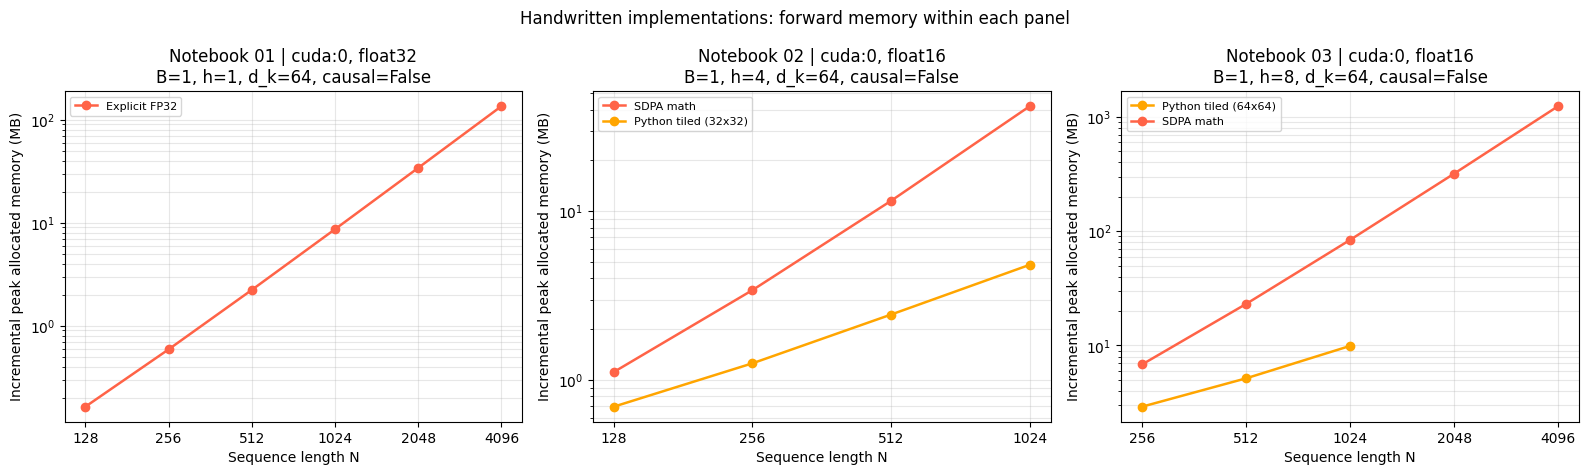

In [7]:
display_names = {
    "simple_attention": "Explicit FP32",
    "standard (math)": "SDPA math",
    "tiled_online": "Python tiled (32x32)",
    "flash_sim (py)": "Python tiled (64x64)",
    "F.sdpa (auto)": "SDPA auto",
    "F.sdpa (default)": "SDPA auto",
    "PyTorch SDPA (auto)": "SDPA auto",
    "Flash (forced)": "Flash forced",
    "fp32_explicit": "Explicit FP32",
    "sdpa_auto_fp32": "SDPA auto FP32",
    "int8_qdq_fp32_compute": "INT8 QDQ + FP32",
    "fp32": "FP32", "dynamic_int8": "Dynamic INT8",
}
colors = {"Explicit FP32": "tomato", "SDPA math": "tomato", "SDPA auto": "steelblue",
          "Python tiled (32x32)": "orange", "Python tiled (64x64)": "orange",
          "Flash forced": "seagreen", "SDPA auto FP32": "steelblue",
          "INT8 QDQ + FP32": "darkorange", "FP32": "steelblue", "Dynamic INT8": "darkorange"}

def config_title(frame):
    columns = ["device", "dtype", "batch", "heads", "d_k", "causal"]
    configs = frame[columns].drop_duplicates()
    if len(configs) != 1:
        raise ValueError("同一张曲线图出现多组配置，请先按设备、精度、形状和掩码筛选")
    row = configs.iloc[0]
    return (f"{row['device']}, {str(row['dtype']).replace('torch.', '')}\n"
            f"B={row['batch']}, h={row['heads']}, d_k={row['d_k']}, causal={row['causal']}")

def plot_series(ax, frame, metric, ylabel, title, log_y=False):
    for impl, group in frame.groupby("impl", sort=False):
        valid = group.dropna(subset=[metric]).sort_values("seq_len")
        if log_y:
            valid = valid.loc[valid[metric].gt(0)]
        if valid.empty:
            continue
        label = display_names.get(impl, impl)
        bounds = ["latency_min_ms", "latency_max_ms"]
        if metric == "latency_ms" and set(bounds).issubset(valid.columns) and valid[bounds].notna().all().all():
            yerr = np.vstack([valid[metric] - valid[bounds[0]], valid[bounds[1]] - valid[metric]])
            ax.errorbar(valid["seq_len"], valid[metric], yerr=yerr, capsize=3, marker="o",
                        linewidth=1.8, color=colors.get(label), label=label)
        else:
            ax.plot(valid["seq_len"], valid[metric], marker="o", linewidth=1.8,
                    color=colors.get(label), label=label)
    ax.set(xlabel="Sequence length N", ylabel=ylabel, title=title)
    ax.set_xscale("log", base=2)
    ticks = sorted(frame["seq_len"].unique())
    ax.set_xticks(ticks, labels=[str(n) for n in ticks])
    if log_y:
        ax.set_yscale("log", base=10)
    ax.grid(alpha=0.3, which="both")
    if ax.lines:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "No measured values", ha="center", transform=ax.transAxes)

own_bench = ok.loc[
    (ok["notebook"].eq("01") & ok["impl"].eq("simple_attention"))
    | (ok["notebook"].eq("02") & ok["impl"].isin(["standard (math)", "tiled_online"]))
    | (ok["notebook"].eq("03") & ok["impl"].isin(["standard (math)", "flash_sim (py)"]))
].copy()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, notebook in zip(axes, ("01", "02", "03")):
    group = own_bench.loc[own_bench["notebook"].eq(notebook)]
    plot_series(ax, group, "memory_mb", "Incremental peak allocated memory (MB)",
                f"Notebook {notebook} | {config_title(group)}", log_y=True)
fig.suptitle("Handwritten implementations: forward memory within each panel")
save_figure(fig, "05_memory_comparison.png")

In [8]:
series_keys = [key for key in match_keys if key != "seq_len"] + ["impl"]
growth_rows = []
for _, group in own_bench.groupby(
    series_keys, dropna=False, sort=False
):
    valid = group.dropna(subset=["memory_mb"]).sort_values("seq_len")
    for i in range(1, len(valid)):
        previous, current = valid.iloc[i - 1], valid.iloc[i]
        if current["seq_len"] == 2 * previous["seq_len"] and previous["memory_mb"] > 0:
            growth_rows.append(dict(notebook=current["notebook"], impl=current["impl"],
                                    from_N=int(previous["seq_len"]), to_N=int(current["seq_len"]),
                                    memory_growth=current["memory_mb"] / previous["memory_mb"]))
growth = pd.DataFrame(growth_rows)
display(growth.round(3))

,notebook,impl,from_N,to_N,memory_growth
0,01,simple_attention,128,256,3.600
1,01,simple_attention,256,512,3.778
2,01,simple_attention,512,1024,3.882
3,01,simple_attention,1024,2048,3.939
4,01,simple_attention,2048,4096,3.969
5,02,standard (math),128,256,3.057
6,02,standard (math),256,512,3.384
7,02,standard (math),512,1024,3.636
8,02,tiled_online,128,256,1.807
9,02,tiled_online,256,512,1.945


01 在 FP32、$B=1,h=1,d_k=64$ 下，序列长度为 $N=1024,2048,4096$ 时，新增显存峰值分别为 **8.651、34.079、135.266 MB**。长序列下，显存占用接近平方增长。

02、03 的分块实现，在各自相同设置下的前向峰值都低于 math。例如 FP16、$B=1,d_k=64,N=1024$、普通注意力、关闭梯度时：

| 实验 | 头数与块形状 | math → 分块实现的新增显存峰值 | math / 分块实现 |
| --- | --- | --- | --- |
| 02 Online Attention | $h=4$，32×32 | 41.948 → 4.820 MB | **8.70×** |
| 03 Flash 风格前向 | $h=8$，64×64 | 83.895 → 9.908 MB | **8.47×** |

这些结果说明，在所列设置下，分块实现减少了前向计算的显存占用。输入转换产生的新张量、输出和临时张量都计入峰值。02 取五轮测量中的最大值，03 使用原运行的一次测量。这里还没有测量反向传播或训练过程的显存峰值。


### 4.2 反向传播需要保留哪些数据？

普通反向计算通常要保存完整权重 $A$，一共有 $BhN^2$ 个元素。重计算方法保留 $Q,K,V,O$ 和每行统计量，需要时重新计算权重和梯度块。不计两种方法都需要的 $Q,K,V$，可作以下比较：

| 方法 | 需要保留的数据 | 元素数量 |
| --- | --- | --- |
| 保存完整权重 | $A$ | $BhN^2$ |
| 2022 年论文中的方法 | $O,m,\ell$ | $Bh(Nd_k+2N)$ |
| 03 反向代码使用的方法 | $O,\mathrm{lse}$ | $Bh(Nd_k+N)$ |

![反向需要保存的数据量估算](../results/03_backward_memory.png)

这张图由 03 按 FP32、单样本单头、$d_k=64$ 计算，比较 $A$ 与 $(O,m,\ell)$ 的数据量，不计共同的 $Q,K,V$。例如 $N=4096$ 时，两者分别约为 **67.109 / 1.081 MB**。计算方法是“元素数量 × 每个元素的字节数”，属于公式估算。

完整的反向过程还需要输入、输出、梯度和当前块的临时空间。当头维度和块大小固定时，重计算方法所需空间随序列长度线性增长。不过，全注意力的计算量仍为 $\Theta(BhN^2d_k)$，分块并没有改变计算量的增长规律。

实际训练还会受到自动求导、其他层、优化器和临时数据分配的影响，训练显存峰值需要另外测量。


## 5 PyTorch 内置注意力的测速对照

03 测量了 PyTorch 提供的三种计算方式：强制 math、强制 Flash 和自动选择的 SDPA。输入均为 FP16、$B=1,h=8,d_k=64$，测量普通注意力的前向计算。这组结果用于了解内置实现的运行效果，项目自己的分块与反向实现见第 3、4 节。

自动 SDPA 会按输入选择计算方式，但本实验没有逐项记录实际选择了哪一种。math 对半精度输入保留 FP32 中间结果，具体说明见 [SDPA 文档](https://docs.pytorch.org/docs/2.11/generated/torch.nn.functional.scaled_dot_product_attention.html)。下面分别列出 Flash 与 math、自动 SDPA 的比较，数据来自 03 原运行的一轮测量。


In [11]:
backend03 = ok.loc[ok['notebook'].eq('03') & ok['impl'].isin(
    ['standard (math)', 'Flash (forced)', 'PyTorch SDPA (auto)']
)].copy()
display(backend03[['seq_len', 'impl', 'latency_ms', 'memory_mb']].sort_values(['seq_len', 'impl']))
at4096 = backend03.loc[backend03['seq_len'].eq(4096)].set_index('impl')
if {'standard (math)', 'Flash (forced)', 'PyTorch SDPA (auto)'}.issubset(at4096.index):
    math_row, flash_row, auto_row = [at4096.loc[name] for name in
                                   ['standard (math)', 'Flash (forced)', 'PyTorch SDPA (auto)']]
    display(Markdown(
        f"在 $N=4096$，math / Flash 的延迟比为 **{math_row['latency_ms']/flash_row['latency_ms']:.2f}×**；"
        f"自动 SDPA / Flash 为 **{auto_row['latency_ms']/flash_row['latency_ms']:.2f}×**。"
        "这些值作为成熟后端性能参照，与手写原型的实现结果分别解释。"
    ))

,seq_len,impl,latency_ms,memory_mb
24,256,Flash (forced),0.077659,0.271360
25,256,PyTorch SDPA (auto),0.025712,0.271360
27,256,standard (math),0.365920,6.818304
28,512,Flash (forced),0.061808,0.541696
29,512,PyTorch SDPA (auto),0.038147,0.541696
31,512,standard (math),0.440998,23.073280
32,1024,Flash (forced),0.210459,1.082368
33,1024,PyTorch SDPA (auto),0.208364,1.082368
35,1024,standard (math),1.450619,83.894784
36,2048,Flash (forced),0.660261,2.163712


在 $N=4096$，math / Flash 的延迟比为 **19.57×**；自动 SDPA / Flash 为 **1.26×**。这些值作为成熟后端性能参照，与手写原型的实现结果分别解释。

## 6 扩展实验：INT8 量化

04 在注意力分块实验之外，补充了量化模拟、CPU 动态 INT8 和小型量化训练示例。QDQ 表示量化后再还原为浮点数；STE（直通估计）用于近似处理量化操作的梯度；QAT（量化感知训练）在训练中模拟量化的影响。

本节比较输出误差、数据大小和运行时间，最后用 Pareto 图观察误差与速度的取舍。

### 6.1 序列长度与输出误差

04 在相同输入下比较不同方法，以自己编写的 FP32 注意力输出为参考。下面固定头数和维度，观察最大绝对误差与相对 L2 误差。相对 L2 误差是输出差值的 L2 范数与参考输出 L2 范数之比。

参考结果与自身比较的误差为 0。这里检查的是输出数值差别，实际模型的准确率还需要在模型和数据集上单独测试。


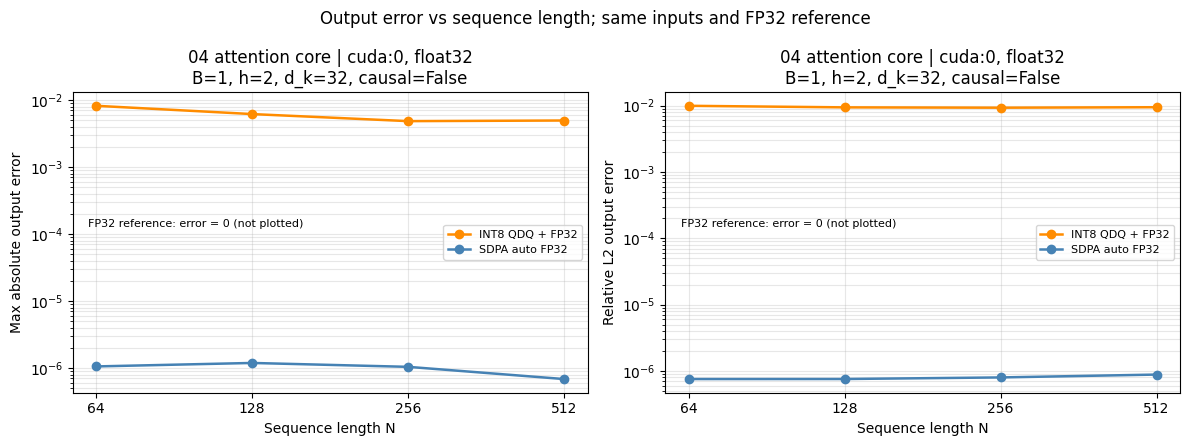

,seq_len,impl,max_abs_error,relative_l2,cosine_similarity
0,64,fp32_explicit,0.000000e+00,0.000000e+00,1.000000
1,64,int8_qdq_fp32_compute,8.204639e-03,9.930185e-03,0.999951
2,64,sdpa_auto_fp32,1.057982e-06,7.556339e-07,1.000000
3,128,fp32_explicit,0.000000e+00,0.000000e+00,1.000000
4,128,int8_qdq_fp32_compute,6.174088e-03,9.402544e-03,0.999956
5,128,sdpa_auto_fp32,1.192093e-06,7.568265e-07,1.000000
6,256,fp32_explicit,0.000000e+00,0.000000e+00,1.000000
7,256,int8_qdq_fp32_compute,4.843920e-03,9.298667e-03,0.999957
8,256,sdpa_auto_fp32,1.043081e-06,7.994679e-07,1.000000
9,512,fp32_explicit,0.000000e+00,0.000000e+00,1.000000


In [12]:
core04 = ok.loc[ok["notebook"].eq("04") & ok["scope"].eq("attention_core")].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric, ylabel in zip(axes, ("max_abs_error", "relative_l2"),
                             ("Max absolute output error", "Relative L2 output error")):
    # 对数轴不能显示 0；参考项单独注明，不加一个人为的小数。
    candidates = core04.loc[~core04["impl"].eq("fp32_explicit")]
    plot_series(ax, candidates, metric, ylabel,
                f"04 attention core | {config_title(core04)}", log_y=True)
    ax.text(0.03, 0.55, "FP32 reference: error = 0 (not plotted)",
            transform=ax.transAxes, fontsize=8)
fig.suptitle("Output error vs sequence length; same inputs and FP32 reference")
save_figure(fig, "05_error_vs_sequence.png")
display(core04[["seq_len", "impl", "max_abs_error", "relative_l2", "cosine_similarity"]]
        .reset_index(drop=True))

在这组输入中，自动 SDPA 的相对 L2 误差约为 $10^{-6}$，INT8 QDQ 模拟约为 $10^{-2}$。前者主要来自不同浮点计算方式的差别，后者还包括量化和还原时的舍入误差。

最大绝对误差没有随序列长度 $N$ 一直增大，相对 L2 误差的变化较小。每个长度使用的随机张量不同，因此这些结果不能说明误差一定随长度增大或减小，也不能直接换算成模型准确率的下降。

### 6.2 量化位数、分组方式与异常值

04 还在 $N=65,d_k=32$ 下比较了 4/6/8-bit 量化，以及逐张量、逐通道和逐 token 三种分组方式。这些方式分别为整个张量、各个通道或各个 token 单独设置量化参数。

下面只使用普通注意力，将常规输入和包含异常大数值的输入分开画图。每张子图内，各种方法使用相同输入。


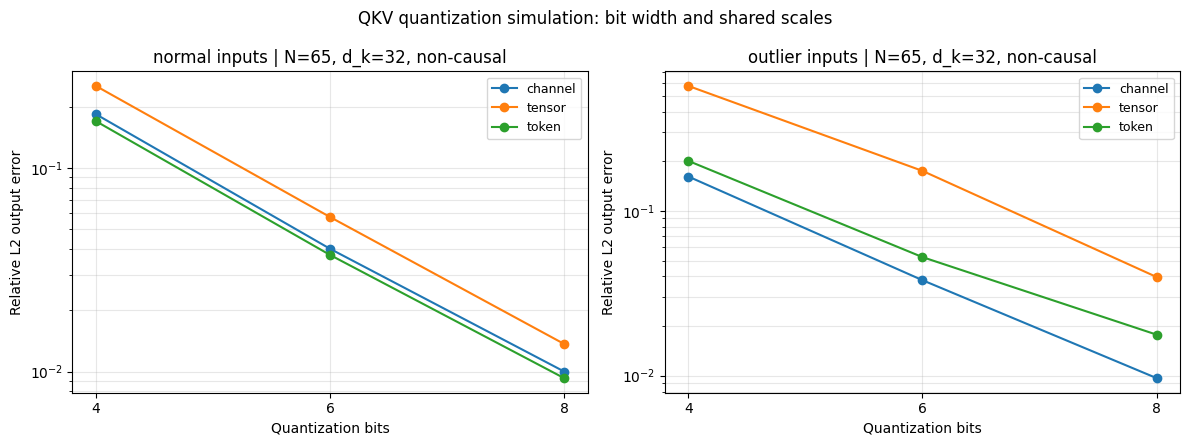

In [13]:
sweep = errors.loc[errors["experiment"].eq("bitwidth_sweep")
                   & errors["causal"].eq(False)].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, distribution in zip(axes, ("normal", "outlier")):
    group = sweep.loc[sweep["distribution"].eq(distribution)]
    for granularity, values in group.groupby("granularity"):
        values = values.sort_values("bits")
        ax.plot(values["bits"], values["relative_l2"], marker="o", label=granularity)
    ax.set(xlabel="Quantization bits", ylabel="Relative L2 output error",
           title=f"{distribution} inputs | N=65, d_k=32, non-causal")
    ax.set_xticks([4, 6, 8])
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=9)
fig.suptitle("QKV quantization simulation: bit width and shared scales")
save_figure(fig, "05_bitwidth_error.png")

在这组实验中，量化位数越多，误差越小。出现异常大数值时，逐张量量化的误差更明显：一个极值会拉大量化间隔，使多数较小数值表示得更粗。逐通道或逐 token 分别设置参数，可以减少不同数值范围之间的影响，在这些输入上的误差更小。

这些图主要比较输出误差。04 的 4/6-bit 结果仍用一个字节保存每个量化值，没有把多个数值压进一个字节，也没有进行对应的低位宽矩阵乘测速，因此实际存储和速度还需要另外检查。


### 6.3 两种量化方法的测速范围

04 的 `int8_qdq_fp32_compute` 先量化、再还原 $Q,K,V$，随后用 FP32 完成注意力计算。计时包括这些步骤，用来观察量化模拟的误差和额外用时。

CPU 的 `dynamic_int8` 将四个投影层换成 PyTorch 的 INT8 Linear。权重转换和打包提前完成，不计入运行时间；运行时对输入的量化包含在计时中。完整 MHA 的注意力部分仍使用浮点计算。接口说明见 [PyTorch 文档](https://docs.pytorch.org/docs/2.11/generated/torch.ao.quantization.quantize_dynamic.html)。

下面分别展示注意力计算、CPU QKV 投影和 CPU 完整 MHA。三者测量的内容不同，各自与同组的浮点结果比较。


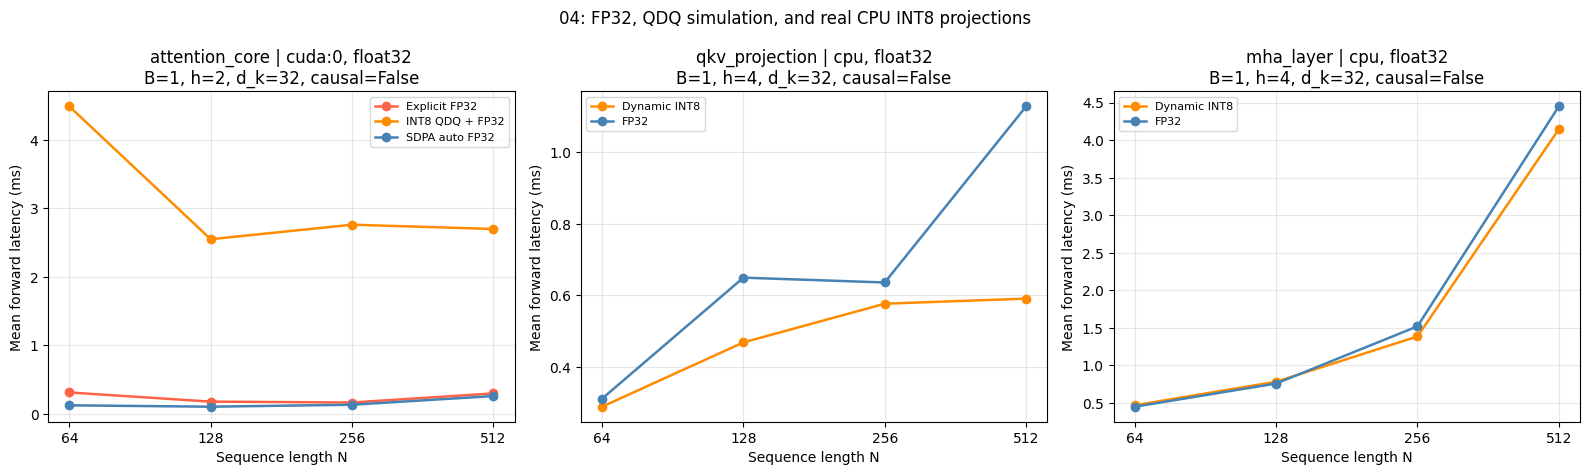

,scope,seq_len,device,latency_ms,baseline_latency_ms,speedup,relative_l2
0,qkv_projection,64,cpu,0.2889,0.3113,1.0777,0.0176
1,qkv_projection,128,cpu,0.4686,0.6497,1.3863,0.0177
2,qkv_projection,256,cpu,0.5768,0.6362,1.1029,0.0200
3,qkv_projection,512,cpu,0.5910,1.1284,1.9091,0.0207
4,mha_layer,64,cpu,0.4672,0.4482,0.9592,0.0208
5,mha_layer,128,cpu,0.7806,0.7570,0.9699,0.0217
6,mha_layer,256,cpu,1.3840,1.5188,1.0974,0.0298
7,mha_layer,512,cpu,4.1440,4.4483,1.0734,0.0296


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, scope in zip(axes, ("attention_core", "qkv_projection", "mha_layer")):
    group = ok.loc[ok["notebook"].eq("04") & ok["scope"].eq(scope)]
    plot_series(ax, group, "latency_ms", "Mean forward latency (ms)",
                f"{scope} | {config_title(group)}")
fig.suptitle("04: FP32, QDQ simulation, and real CPU INT8 projections")
save_figure(fig, "05_quantization_latency.png")

cpu_comparisons = comparisons.loc[comparisons["notebook"].eq("04")
                                  & comparisons["impl"].eq("dynamic_int8")]
display(cpu_comparisons[["scope", "seq_len", "device", "latency_ms", "baseline_latency_ms",
                         "speedup", "relative_l2"]].round(4).reset_index(drop=True))

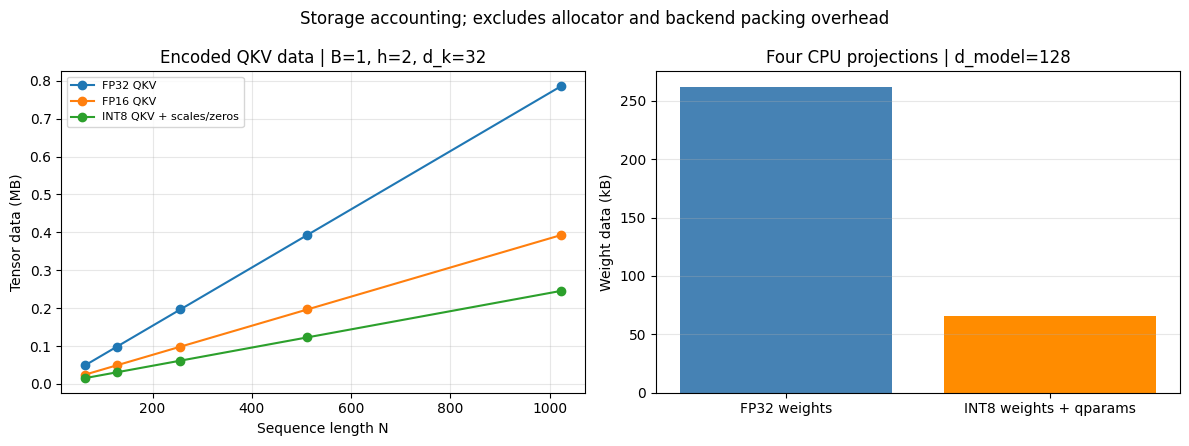

,impl,device,d_model,weight_storage_bytes,storage_metric
0,mha_fp32,cpu,128,262144,weight_data_and_qparams_excluding_packing
1,mha_dynamic_int8,cpu,128,65600,weight_data_and_qparams_excluding_packing


,seq_len,batch,heads,d_k,qkv_fp32_bytes,qkv_fp16_bytes,qkv_int8_with_params_bytes,metric,fp32_over_int8,fp16_over_int8
0,64,1,2,32,49152,24576,15360,tensor_data_bytes_excluding_allocator,3.2,1.6
1,128,1,2,32,98304,49152,30720,tensor_data_bytes_excluding_allocator,3.2,1.6
2,256,1,2,32,196608,98304,61440,tensor_data_bytes_excluding_allocator,3.2,1.6
3,512,1,2,32,393216,196608,122880,tensor_data_bytes_excluding_allocator,3.2,1.6
4,1024,1,2,32,786432,393216,245760,tensor_data_bytes_excluding_allocator,3.2,1.6


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for column, label in [("qkv_fp32_bytes", "FP32 QKV"), ("qkv_fp16_bytes", "FP16 QKV"),
                      ("qkv_int8_with_params_bytes", "INT8 QKV + scales/zeros")]:
    axes[0].plot(qkv_storage["seq_len"], qkv_storage[column] / 1e6,
                 marker="o", label=label)
axes[0].set(xlabel="Sequence length N", ylabel="Tensor data (MB)",
            title="Encoded QKV data | B=1, h=2, d_k=32")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

weight_labels = {"mha_fp32": "FP32 weights", "mha_dynamic_int8": "INT8 weights + qparams"}
axes[1].bar([weight_labels.get(name, name) for name in weight_storage["impl"]],
            weight_storage["weight_storage_bytes"] / 1e3, color=["steelblue", "darkorange"])
axes[1].set(ylabel="Weight data (kB)", title="Four CPU projections | d_model=128")
axes[1].grid(axis="y", alpha=0.3)
fig.suptitle("Storage accounting; excludes allocator and backend packing overhead")
save_figure(fig, "05_storage_comparison.png")

display(weight_storage)
display(qkv_storage.assign(
    fp32_over_int8=qkv_storage["qkv_fp32_bytes"] / qkv_storage["qkv_int8_with_params_bytes"],
    fp16_over_int8=qkv_storage["qkv_fp16_bytes"] / qkv_storage["qkv_int8_with_params_bytes"],
).round(3))

In [16]:
observations = []
weight_values = weight_storage.set_index("impl")["weight_storage_bytes"]
if {"mha_fp32", "mha_dynamic_int8"}.issubset(weight_values.index):
    fp32_bytes, int8_bytes = weight_values["mha_fp32"], weight_values["mha_dynamic_int8"]
    observations.append(f"四个投影的权重数据从 {fp32_bytes / 1e3:.3f} kB 降到 "
                        f"{int8_bytes / 1e3:.3f} kB，约压缩 {fp32_bytes / int8_bytes:.2f} 倍。"
                        "这项统计计入量化参数，排除打包、对齐和 Python 对象开销。")
for scope in ("qkv_projection", "mha_layer"):
    group = cpu_comparisons.loc[cpu_comparisons["scope"].eq(scope)].sort_values("seq_len")
    if not group.empty:
        faster = group.loc[group["speedup"].gt(1), "seq_len"].astype(str).tolist()
        faster_text = (f"本次测量中 INT8 更快的测点是 $N={', '.join(faster)}$。"
                       if faster else "在已测长度中均未获得加速。")
        observations.append(f"CPU `{scope}` 的加速比范围是 {group['speedup'].min():.2f}–"
                            f"{group['speedup'].max():.2f}；{faster_text}")
qdq_comparisons = comparisons.loc[comparisons["notebook"].eq("04")
                                  & comparisons["impl"].eq("int8_qdq_fp32_compute")]
if not qdq_comparisons.empty:
    observations.append(f"QDQ 模拟的 FP32 基准 / 当前延迟为 "
                        f"{qdq_comparisons['speedup'].min():.2f}–"
                        f"{qdq_comparisons['speedup'].max():.2f}，这些测点均未获得加速。")
display(Markdown("**把存储和延迟放在一起看：**\n\n" + "\n\n".join(observations)))

**把存储和延迟放在一起看：**

四个投影的权重数据从 262.144 kB 降到 65.600 kB，约压缩 4.00 倍。这项统计计入量化参数，排除打包、对齐和 Python 对象开销。

CPU `qkv_projection` 的加速比范围是 1.08–1.91；本次测量中 INT8 更快的测点是 $N=64, 128, 256, 512$。

CPU `mha_layer` 的加速比范围是 0.96–1.10；本次测量中 INT8 更快的测点是 $N=256, 512$。

QDQ 模拟的 FP32 基准 / 当前延迟为 0.06–0.11，这些测点均未获得加速。

### 6.4 数据压缩与实际运行速度

量化后，数据可以更小，但运行时还要计算量化参数、转换数值并调用相应算子。对于小矩阵，这些步骤可能占据较多时间。完整 MHA 还包含浮点注意力计算，所以投影层变快不一定使整个 MHA 同样变快。

CPU 完整 MHA 共测了 4 组长度，其中动态 INT8 在 2 组中比 FP32 用时更短，具体比值见上表。这些结果来自原运行，还需要多轮测速来检查较小的速度差别。QDQ 模拟使用 FP32 矩阵乘，并增加了转换步骤和临时张量，显存和速度需要实测。

量化后的 $Q,K,V$ 除了整数值，还保存缩放系数（scale）和零点（zero-point），所以实际数据量大于只计算整数值时的数据量。对称量化的零点固定为 0，04 为统一数据格式仍保存了它。量化数据大小、权重大小和计算中的显存峰值分别统计。

### 6.5 误差与速度的取舍

最后读取 04 保存的 Pareto 结果，固定 $N=256$。如果一个方法的误差和用时都不比另一个方法更好，就没有明显的选择优势；如果一个方法更快但误差更大，两者就各有优点。

具体判断时，若另一个方法用时不更多、误差不更大，并且至少有一项更好，当前方法就不进入 Pareto 前沿。星号表示已测方法中保留下来的折中方案。


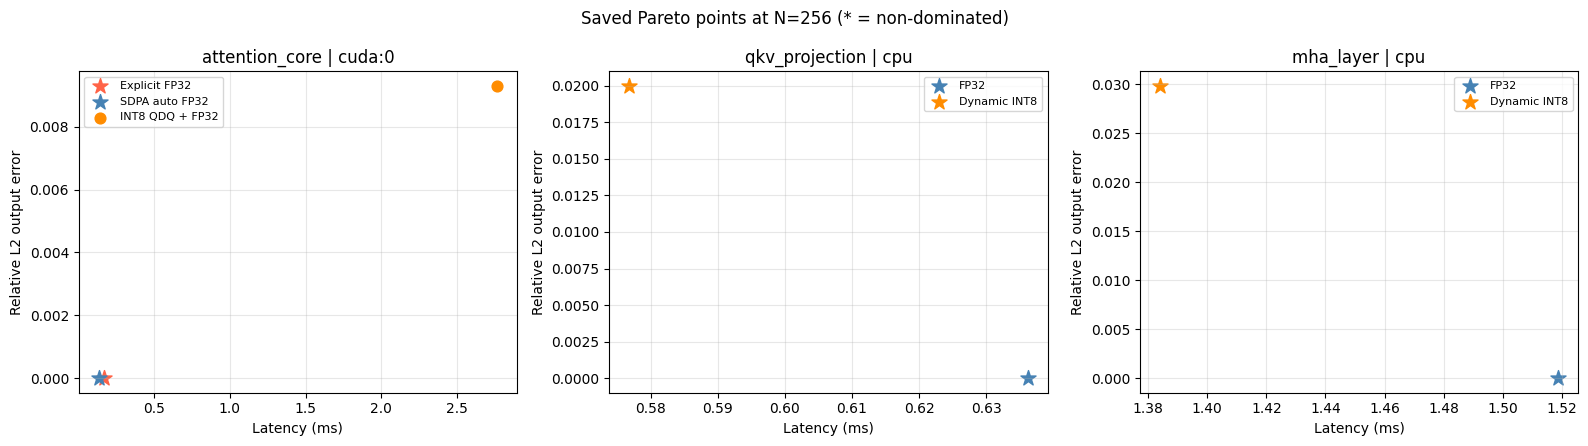

,scope,seq_len,device,impl,latency_ms,relative_l2,on_front
0,attention_core,256,cuda:0,fp32_explicit,0.166319,0.000000e+00,True
1,attention_core,256,cuda:0,sdpa_auto_fp32,0.134012,7.994679e-07,True
2,attention_core,256,cuda:0,int8_qdq_fp32_compute,2.763360,9.298667e-03,False
3,qkv_projection,256,cpu,fp32,0.636167,0.000000e+00,True
4,qkv_projection,256,cpu,dynamic_int8,0.576808,1.999140e-02,True
5,mha_layer,256,cpu,fp32,1.518758,0.000000e+00,True
6,mha_layer,256,cpu,dynamic_int8,1.384016,2.982477e-02,True


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, scope in zip(axes, ("attention_core", "qkv_projection", "mha_layer")):
    group = pareto.loc[pareto["scope"].eq(scope)]
    for row in group.to_dict("records"):
        label = display_names.get(row["impl"], row["impl"])
        ax.scatter(row["latency_ms"], row["relative_l2"],
                   marker="*" if row["on_front"] else "o", s=130 if row["on_front"] else 60,
                   color=colors.get(label), label=label)
    device_label = ", ".join(group["device"].unique()) if not group.empty else "no data"
    ax.set(xlabel="Latency (ms)", ylabel="Relative L2 output error",
           title=f"{scope} | {device_label}")
    ax.grid(alpha=0.3)
    if not group.empty:
        ax.legend(fontsize=8)
fig.suptitle("Saved Pareto points at N=256 (* = non-dominated)")
save_figure(fig, "05_accuracy_latency.png")
display(pareto.reset_index(drop=True))

在本次 $N=256$ 的实验中：

- **GPU 注意力计算**：QDQ + FP32 的误差更大、用时也更长，因此没有进入图中标出的折中方案。
- **CPU QKV 投影与完整 MHA**：动态 INT8 用时更短，但输出误差更大。它和 FP32 各有优点，都进入了图中标出的折中方案。

图中只比较这一长度下的误差和用时，没有把权重大小算作一个指标。实际选择方法时，还需要考虑存储限制、测速波动和模型任务准确率。


## 7 实验不足与后续计划

目前的输出和梯度检查只覆盖测试过的输入及精度。03 用独立函数检查重计算反向，还没有接入训练，也没有测量实际训练的显存峰值。普通分块代码直接使用 PyTorch 自动求导时，仍可能保存较多中间结果。

本项目用 PyTorch 的张量操作表达算法。论文讨论的数据读写量和片上存储复用是理论分析，普通 PyTorch 代码不能保证数据块一直留在 GPU 的片上存储中，实际数据传输量也尚未测量。04 的 QAT 只使用小线性层，实际模型的任务表现需要进一步测试。


### 7.1 Python 实现的运行时间与复测

Python 实现主要用于检查更新和梯度公式，代码中使用较多循环、独立的张量操作和 FP32 中间计算，运行速度受到限制。下面保留实际用时和波动范围，具体每一步用了多少时间还没有用性能分析工具统计。

用时图采用对数刻度，02 的误差条表示五轮平均用时的最小值到最大值。02 每轮预热 5 次、计时 10 次，共 5 轮，最终取五个平均值的中位数；03 使用原运行中预热后 20 次调用的平均值。

旧 02 结果中，$N=1024$ 的用时反而明显低于 $N=512$，因此已对四种长度、三种实现重新测量五轮，汇总使用新的结果。旧异常的原因目前还不能确定。复测后，各方法的用时中位数在这些长度上没有随长度增加而下降；不过，$N=1024$ 的 Python 实现每轮平均用时仍在 **2.43–5.71 秒**之间，波动较大。


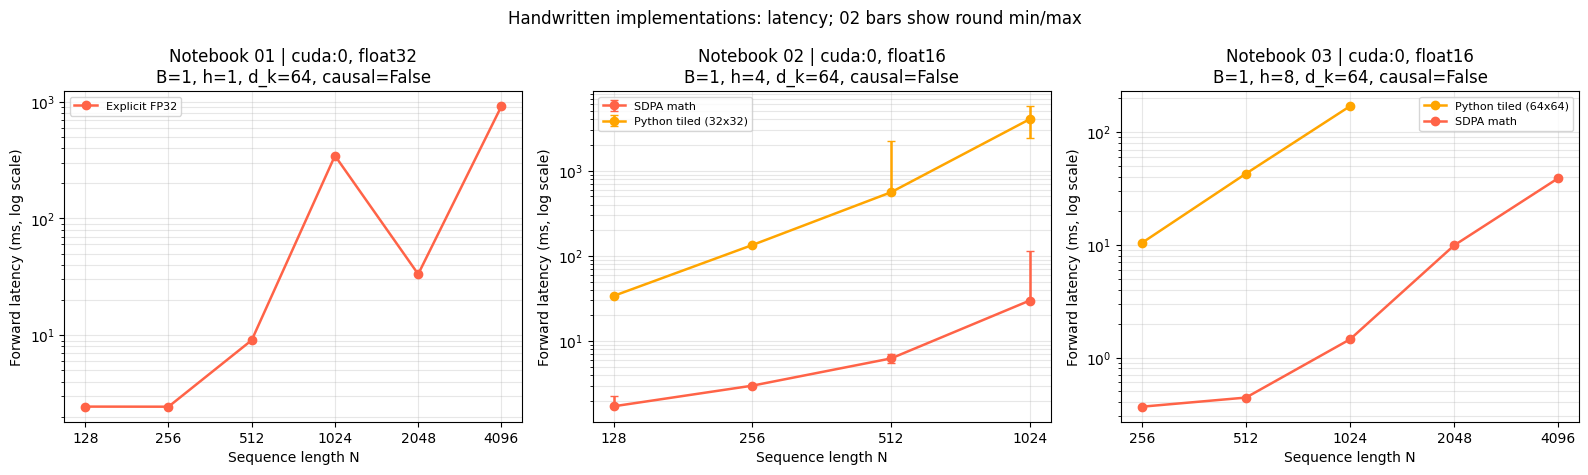

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, notebook in zip(axes, ("01", "02", "03")):
    group = own_bench.loc[own_bench["notebook"].eq(notebook)]
    plot_series(ax, group, "latency_ms", "Forward latency (ms, log scale)",
                f"Notebook {notebook} | {config_title(group)}", log_y=True)
fig.suptitle("Handwritten implementations: latency; 02 bars show round min/max")
save_figure(fig, "05_latency_comparison.png")

In [10]:
own_comparisons = comparisons.loc[comparisons['impl'].isin(['tiled_online', 'flash_sim (py)'])].copy()
display(own_comparisons[['notebook', 'seq_len', 'impl', 'baseline_latency_ms', 'latency_ms',
                         'speedup', 'baseline_memory_mb', 'memory_mb', 'memory_ratio']].round(4))
retest02 = ok.loc[ok['notebook'].eq('02')].sort_values(['impl', 'seq_len'])
display(retest02[['seq_len', 'impl', 'latency_ms', 'latency_min_ms', 'latency_max_ms',
                  'timing_rounds', 'latency_aggregation', 'memory_mb']].reset_index(drop=True))
retest_ranges = retest02.assign(
    round_max_over_min=retest02['latency_max_ms'] / retest02['latency_min_ms']
)
display(retest_ranges.groupby('impl')['round_max_over_min'].max().rename('最大轮间延迟比').reset_index())
for impl, group in retest02.groupby('impl'):
    group = group.sort_values('seq_len')
    monotonic = bool(group['latency_ms'].is_monotonic_increasing)
    print(f"{impl}: 延迟中位数随已测长度单调不减={monotonic}；不强制短序列延迟单调。")

,notebook,seq_len,impl,baseline_latency_ms,latency_ms,speedup,baseline_memory_mb,memory_mb,memory_ratio
7,02,128,tiled_online,1.7193,33.8908,0.0507,1.1151,0.6953,1.6038
9,02,256,tiled_online,3.0026,134.0407,0.0224,3.4094,1.2564,2.7135
11,02,512,tiled_online,6.2678,557.7339,0.0112,11.5369,2.4443,4.7199
13,02,1024,tiled_online,29.9422,4016.9205,0.0075,41.9476,4.8200,8.7029
16,03,256,flash_sim (py),0.3659,10.4101,0.0352,6.8183,2.9123,2.3412
19,03,512,flash_sim (py),0.4410,42.8898,0.0103,23.0733,5.1569,4.4743
22,03,1024,flash_sim (py),1.4506,170.1943,0.0085,83.8948,9.9082,8.4672


,seq_len,impl,latency_ms,latency_min_ms,latency_max_ms,timing_rounds,latency_aggregation,memory_mb
0,128,F.sdpa (default),0.294109,0.284754,0.845769,5,median_of_round_means,0.068608
1,256,F.sdpa (default),0.481096,0.464327,1.030549,5,median_of_round_means,0.136192
2,512,F.sdpa (default),0.875632,0.851002,1.331842,5,median_of_round_means,0.271360
3,1024,F.sdpa (default),3.498654,3.478280,15.906826,5,median_of_round_means,0.541696
4,128,standard (math),1.719324,1.701113,2.250814,5,median_of_round_means,1.115136
5,256,standard (math),3.002560,2.998693,3.011655,5,median_of_round_means,3.409408
6,512,standard (math),6.267821,5.581314,7.089605,5,median_of_round_means,11.536896
7,1024,standard (math),29.942230,29.709016,115.201153,5,median_of_round_means,41.947648
8,128,tiled_online,33.890794,33.423242,35.086969,5,median_of_round_means,0.695296
9,256,tiled_online,134.040666,132.948949,134.715347,5,median_of_round_means,1.256448


,impl,最大轮间延迟比
0,F.sdpa (default),4.573188
1,standard (math),3.877650
2,tiled_online,4.155835


F.sdpa (default): 延迟中位数随已测长度单调不减=True；不强制短序列延迟单调。
standard (math): 延迟中位数随已测长度单调不减=True；不强制短序列延迟单调。
tiled_online: 延迟中位数随已测长度单调不减=True；不强制短序列延迟单调。


表中加速比为 $t_{\mathrm{baseline}}/t_{\mathrm{method}}$，大于 1 表示当前方法更快；显存比为 $M_{\mathrm{baseline}}/M_{\mathrm{method}}$。显存结果的分析见第 4 节。

在本次设置下，两种 Python 分块实现的用时都长于各自的 math 对照。循环中多次进行矩阵乘、指数、求和、缩放和类型转换，可能带来较多额外用时，但各项耗时还没有实际统计。02 的复测反映本次运行的波动，03 还需要按相同方法进行多轮测速。


### 7.2 后续计划

| 计划 | 想进一步了解的问题 | 检查方法 |
| --- | --- | --- |
| 增加输入和分块设置 | 换序列长度、块大小、精度和掩码后，输出与梯度是否仍正确 | 与参考结果比较，检查不完整块和整行被遮住的局部块 |
| 将反向函数接入训练 | 实际训练能减少多少显存占用 | 分别测量前向、反向峰值，统计保存的张量 |
| 对 01、03、04 进行多轮测速 | 用时是否稳定，较小的速度差别能否重复观察到 | 保存每轮结果，比较中位数和波动范围 |
| 在模型和数据集上测试量化 | 输出误差会怎样影响实际任务 | 测量任务准确率、推理用时和存储大小 |
| 测试不同块大小并分析耗时 | 哪些操作占用较多时间 | 比较误差、显存和用时，使用性能分析工具查看各操作耗时 |

### 7.3 结果文件导出

下面导出四份 CSV 和结果摘要，保留数据来源、实验设置、成功 / 跳过状态和统计方法。上游 notebook 重新运行后，再运行本节更新汇总。需要读取的文件列在摘要中，包括 02 导出的检查结果 JSON。


In [18]:
storage_rows = []
for row in qkv_storage.to_dict("records"):
    for key, impl in [("qkv_fp32_bytes", "fp32"), ("qkv_fp16_bytes", "fp16"),
                      ("qkv_int8_with_params_bytes", "int8_with_params")]:
        storage_rows.append(dict(scope="qkv_encoded_data", seq_len=row["seq_len"],
                                 batch=row["batch"], heads=row["heads"], d_k=row["d_k"],
                                 impl=impl, data_bytes=row[key], metric=row["metric"]))
for row in weight_storage.to_dict("records"):
    storage_rows.append(dict(scope="four_projection_weights", device=row["device"],
                             d_model=row["d_model"], impl=row["impl"],
                             data_bytes=row["weight_storage_bytes"], metric=row["storage_metric"]))
storage_summary = pd.DataFrame(storage_rows)

exports = {"05_benchmark_summary.csv": bench,
           "05_comparison_ratios.csv": comparisons,
           "05_quantization_errors.csv": errors,
           "05_storage_summary.csv": storage_summary}
for filename, frame in exports.items():
    frame.to_csv(results_dir / filename, index=False, encoding="utf-8-sig", na_rep="")

# DataFrame 的空值转换成 JSON null，禁止输出 NaN。
summary = {
    "benchmark_rows": len(bench),
    "analysis_inputs": list(benchmark_files.values()) + [
        "02_validation_online_softmax.json", "04_quantization_error.json",
        "04_quantization_storage.json", "04_quantization_tools.json",
        "04_pareto.json", "04_environment.json"],
    "validation_02": {"forward_checks_passed": len(forward_checks02),
                      "precision_checks_passed": len(precision_checks02)},
    "timing_protocol_02": {"rounds": 5, "iterations_per_round": 10,
                           "latency": "median_of_round_means", "error_bars": "round_min_max"},
    "status_counts": json.loads(bench.groupby(["notebook", "scope", "status"])
                                .size().rename("count").reset_index().to_json(orient="records")),
    "original_environment_04": environment,
    "memory_metric": "incremental_peak_allocated",
    "memory_unit": "MB = 1000000 bytes",
    "ratio_definition": "baseline / candidate; speedup > 1 means candidate is faster",
    "flash_forced_successful_rows": int(((bench["impl"] == "Flash (forced)")
                                         & (bench["status"] == "ok")).sum()),
    "auto_backend_recorded": False,
    "csv_files": list(exports),
}
(results_dir / "05_analysis_summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8"
)
print("已保存 4 份 CSV、05_analysis_summary.json 和本节的 7 张图。")

已保存 4 份 CSV、05_analysis_summary.json 和本节的 7 张图。


## 8 参考资料与结果文件

**汇总结果**

- [性能汇总表](../results/05_benchmark_summary.csv)：数据来源、实验设置、运行状态和原始结果。
- [比较结果](../results/05_comparison_ratios.csv)：对照方法与当前方法的时间、显存比值。
- [量化误差](../results/05_quantization_errors.csv)、[数据大小汇总](../results/05_storage_summary.csv)。
- [结果摘要](../results/05_analysis_summary.json)：记录数量与指标说明；[运行环境](../results/environment.json)：版本及五份 notebook 的执行记录。

**原始实验文件**

- [02 输出与精度检查](../results/02_validation_online_softmax.json)。
- [标准注意力测速](../results/01_benchmark_standard_attention.json)、[Online Softmax 测速](../results/02_benchmark_online_softmax.json)、[FlashAttention / SDPA 测速](../results/03_benchmark_flash_attention.json)。
- [反向保存数据量估算图](../results/03_backward_memory.png)。
- [量化测速](../results/04_benchmark_quantization.json)、[量化误差](../results/04_quantization_error.json)、[存储统计](../results/04_quantization_storage.json)、[Pareto 结果](../results/04_pareto.json)。

**参考资料**

- [Online normalizer calculation for softmax](https://arxiv.org/abs/1805.02867)。
- [FlashAttention，NeurIPS 2022，本地 PDF](https://arxiv.org/abs/2205.14135)。
- [FlashAttention-2](https://arxiv.org/abs/2307.08691)。
- [PyTorch 2.11 SDPA 文档](https://docs.pytorch.org/docs/2.11/generated/torch.nn.functional.scaled_dot_product_attention.html)。
- [PyTorch 2.11 动态量化接口](https://docs.pytorch.org/docs/2.11/generated/torch.ao.quantization.quantize_dynamic.html)。
